# DS4200 Homework 9

Due: Friday Apr 3rd @ 11:59 PM EST

### Submission Instructions
Submit this `ipynb` file included with the coding results to Gradescope (this can also be done via the assignment on Canvas).  To ensure that your submitted files represent your latest code, make sure to give a fresh `Kernel > Restart & Run All` just before uploading the files to gradescope.

### Tips for success
- Start early
- Make use of Piazza
- Make use of Office hour
- Remember to use cells and headings to make the notebook easy to read (if a grader cannot find the answer to a problem, you will receive no points for it)
- Under no circumstances may one student view or share their ungraded homework or quiz with another student [(see also)](http://www.northeastern.edu/osccr/academic-integrity), though you are welcome to **talk about** (not show each other) the problems.

### Part 1 Analysis the Wolfe Primates

These data represent 3 months of interactions among a troop of monkeys, observed in the wild by Linda Wolfe as they sported by a river in Ocala, Florida. Joint presence at the river was coded as an interaction and these were summed within all pairs. 

There are two files for the data. `labels.csv` is the file contains information for each monkey, with their genders, ages and their rank in the troop. `link_m.csv` is the file contains the number of their interaction in the adjacency matrix format. Note, there is no header in hte `link_m.csv`.

#### Part 1.1 Visualize the adjacency matrix (10 points)

Load the data and **reorder the link matrix based on rank**. For example, suppose the original data table is:

|   | ID | Sex    | Age | Rank |
|--:|---:|--------|----:|------|
| 0 |  0 | female |  12 |    3 |
| 1 |  1 | male   |   9 |    2 |
| 2 |  2 | male   |  15 |    1 |
| 3 |  3 | male   |   7 |    5 |
| 4 |  4 | female |   4 |    4 |

You should reorder **both the rows and columns** of the `link_m` matrix according to the rank order `[3, 2, 1, 5, 4]`. Note that the rank values start at **1**, while matrix indices start at **0**, so you must subtract **1** from each rank value before using it as an index for reordering.

Finally, provide an appropriate **title** and **axis labels** for the resulting plot.
        

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
labels = pd.read_csv('labels.csv')
labels.head()

,Id,Sex,Age,Rank
0,0,male,15,1
1,1,male,10,2
2,2,male,10,3
3,3,male,8,4
4,4,male,7,5


In [3]:
link_m = pd.read_csv('link_m.csv', header = None)
link_m

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,2,10,4,5,5,9,7,4,3,3,7,3,2,5,1,4,1,0,1
1,2,0,5,1,3,1,4,2,6,2,5,4,3,2,2,6,3,1,1,1
2,10,5,0,8,9,5,11,7,8,8,14,17,9,11,11,5,9,4,6,5
3,4,1,8,0,4,0,3,4,2,3,5,3,11,4,7,0,4,3,3,0
4,5,3,9,4,0,3,5,7,4,3,5,6,3,4,4,1,2,1,3,3
5,5,1,5,0,3,0,5,2,3,2,2,4,4,3,1,1,2,0,1,2
6,9,4,11,3,5,5,0,5,4,6,3,9,5,5,4,2,6,3,2,2
7,7,2,7,4,7,2,5,0,3,0,3,4,2,1,3,0,1,1,1,0
8,4,6,8,2,4,3,4,3,0,1,3,2,4,5,4,3,4,1,3,2
9,3,2,8,3,3,2,6,0,1,0,4,7,5,5,7,2,2,3,3,2


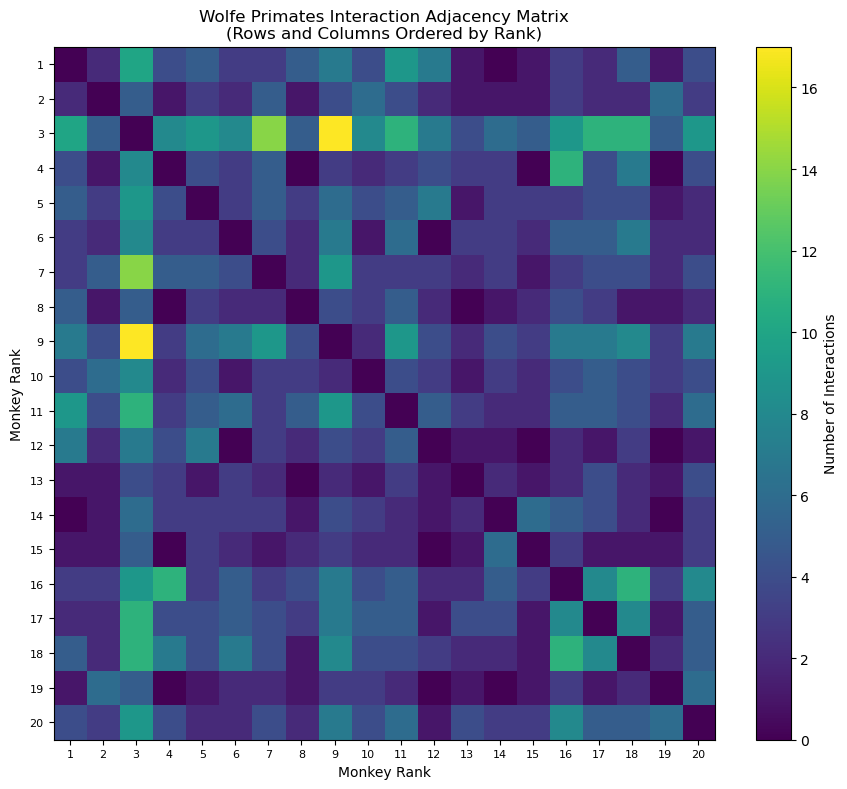

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

labels = pd.read_csv('labels.csv')
link_m = pd.read_csv('link_m.csv', header=None)

rank_order = labels['Rank'].values - 1

link_reordered = link_m.values[np.ix_(rank_order, rank_order)]

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(link_reordered, cmap='viridis', aspect='auto')

ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xticklabels(range(1, 21), fontsize=8)
ax.set_yticklabels(range(1, 21), fontsize=8)

ax.set_xlabel('Monkey Rank')
ax.set_ylabel('Monkey Rank')
ax.set_title('Wolfe Primates Interaction Adjacency Matrix\n(Rows and Columns Ordered by Rank)')

plt.colorbar(im, ax=ax, label='Number of Interactions')
plt.tight_layout()
plt.savefig('adjacency_matrix.png', dpi=150)
plt.show()

#### Part 1.2 edgelist (10 points)

Convert the data into an **edge list data frame** with three columns: **source**, **target**, and **weight**. The **source** and **target** columns should contain the IDs of the monkeys, and the **weight** column should store the corresponding values from the link matrix, representing the number of interactions between each pair of monkeys.


In [6]:
rows, cols = np.where(link_m.values > 0)

edge_list = pd.DataFrame({
    'source': rows,
    'target': cols,
    'weight': link_m.values[rows, cols]
})

edge_list

,source,target,weight
0,0,1,2
1,0,2,10
2,0,3,4
3,0,4,5
4,0,5,5
...,...,...,...
357,19,14,1
358,19,15,1
359,19,16,3
360,19,17,1


#### Part 1.3 Make a static network (15 points)

Using the edge list generated in **Part 1.2**, construct a **bipartite network** in which one partition represents **male** nodes and the other represents **female** nodes. Encode **gender** using node color and **age** using node size. Encode **edge weight** using the width of the links. You may adjust the scaling of node sizes and edge widths as needed to ensure the network is visually clear and interpretable.

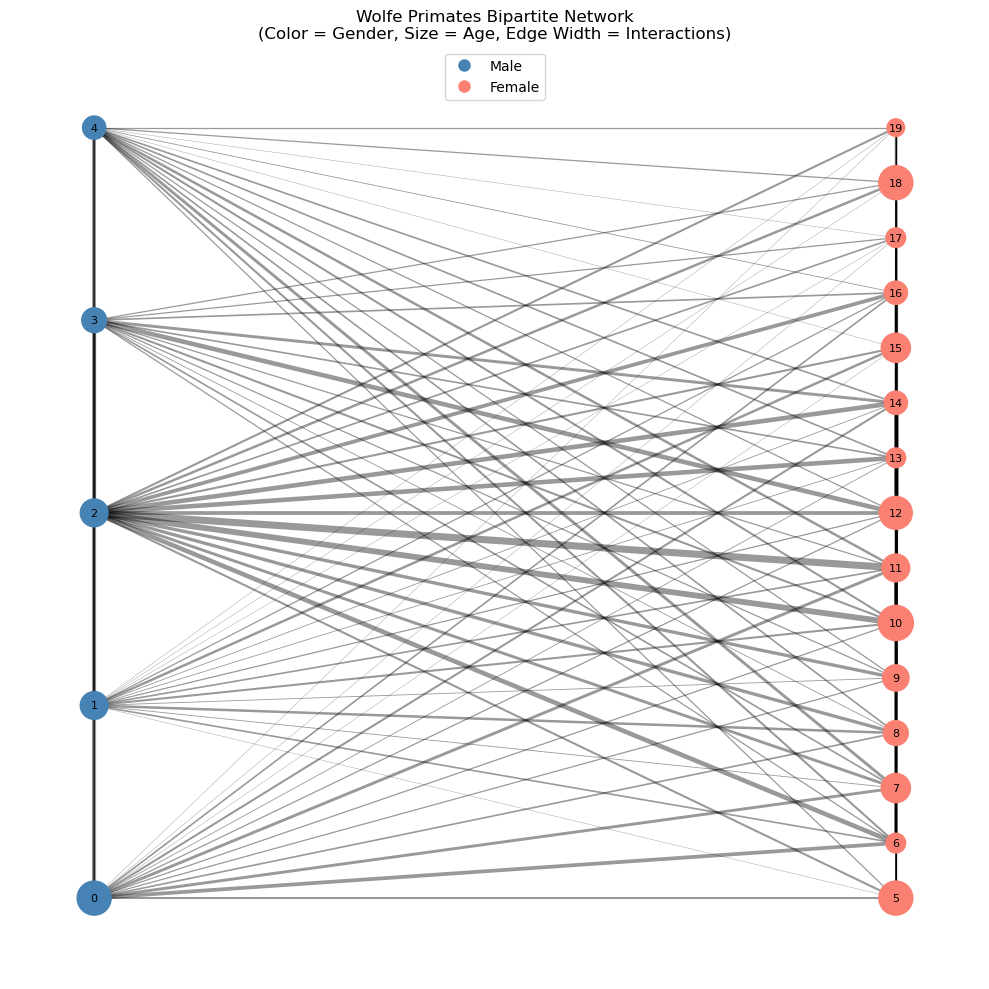

In [ ]:
G = nx.Graph()

for _, row in labels.iterrows():
    G.add_node(row['Id'], sex=row['Sex'], age=row['Age'])

# Add edges with weights (use undirected, so avoid duplicates)
for _, row in edge_list[edge_list['source'] < edge_list['target']].iterrows():
    G.add_edge(int(row['source']), int(row['target']), weight=row['weight'])

males = [n for n, d in G.nodes(data=True) if d['sex'] == 'male']
females = [n for n, d in G.nodes(data=True) if d['sex'] == 'female']

pos = {}
male_spacing = (len(females) - 1) / (len(males) - 1)
for i, node in enumerate(males):
    pos[node] = (0, i * male_spacing)
for i, node in enumerate(females):
    pos[node] = (1, i)

node_colors = ['steelblue' if G.nodes[n]['sex'] == 'male' else 'salmon' for n in G.nodes()]

node_sizes = [G.nodes[n]['age'] * 40 for n in G.nodes()]

edges = G.edges(data=True)
edge_widths = [d['weight'] * 0.3 for _, _, d in edges]

fig, ax = plt.subplots(figsize=(10, 10))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Male'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='salmon', markersize=10, label='Female'),
]
ax.legend(handles=legend_elements, loc='upper center')

ax.set_title('Wolfe Primates Bipartite Network\n(Color = Gender, Size = Age, Edge Width = Interactions)')
ax.axis('off')
plt.tight_layout()
plt.savefig('bipartite_network.png', dpi=150)
plt.show()

### Part 2 Brokerage and Closure in social networks (25 points)

#### Part 2.1 Concepts (5 points)

Use an AI tool (e.g., ChatGPT) to learn about the concepts of brokerage and closure in social networks. In your **own words**, briefly describe:
- What is **closure** in a social network?
- What is **brokerage** in a social network?
- Highlight **at least two key differences** between these two concepts. (Hint: a network with more closure vs. a network with more brokerage, how would they be different from each other? If I randomly remove a link from the network, what will happen to each type of the network?)


Closure in a social network refers to the tendency for connections to form between nodes that share a mutual connection, meaning "friends of friends become friends." A network with high closure has many tightly knit clusters where everyone within a group knows each other, forming lots of triangles.

Brokerage refers to a node's role as a bridge between two otherwise disconnected groups. A broker sits between clusters and controls the flow of information or resources across them, holding a structurally advantageous position.

Two key differences:

* Redundancy vs. uniqueness of connections: In a high-closure network, relationships are redundant, so if one link is removed, information can still flow through alternative paths within the cluster. In a high-brokerage network, connections are unique and non-redundant. If the bridge link connecting two groups is removed, those groups become completely disconnected with no alternative path.
* Information flow: High-closure networks tend to circulate the same information within a tight group, leading to shared norms and trust but limited exposure to new ideas. High-brokerage networks give brokers access to diverse information from multiple groups, making them more likely to encounter and spread novel ideas across the network.

#### Part 2.2 Simulation (5 points)

Use AI to help you generate **two adjacency matrices**:
- A matrix representing **a closure-based network**
- A matrix representing **a brokerage-based network**
Requirements:
- Each matrix should represent a network with **at least 10 nodes**
- Make sure your nodes have **labels** (row names and column names), either by names or IDs
- **Save each matrix in a seperate csv file. Attach the csv file in the homework submission.**

In [9]:
import pandas as pd
import numpy as np

nodes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

closure = np.array([
    #A  B  C  D  E  F  G  H  I  J
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # A
    [1, 0, 1, 1, 1, 0, 0, 0, 0, 0],  # B
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],  # C
    [1, 1, 1, 0, 1, 0, 0, 0, 0, 0],  # D
    [1, 1, 1, 1, 0, 1, 0, 0, 0, 0],  # E 
    [0, 0, 0, 0, 1, 0, 1, 1, 1, 1],  # F
    [0, 0, 0, 0, 0, 1, 0, 1, 1, 1],  # G
    [0, 0, 0, 0, 0, 1, 1, 0, 1, 1],  # H
    [0, 0, 0, 0, 0, 1, 1, 1, 0, 1],  # I
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 0],  # J
])


brokerage = np.array([
    #A  B  C  D  E  F  G  H  I  J
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # A
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # B
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # C
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # D
    [1, 1, 1, 1, 0, 1, 1, 1, 1, 1],  # E 
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # F
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # G
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # H
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # I
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # J
])

pd.DataFrame(closure, index=nodes, columns=nodes).to_csv('closure_network.csv')
pd.DataFrame(brokerage, index=nodes, columns=nodes).to_csv('brokerage_network.csv')

print("Saved closure_network.csv and brokerage_network.csv")

Saved closure_network.csv and brokerage_network.csv


#### Part 2.3 Visualization (10 points)

For each of the adjacency matrix:
- Load the adjacency matrix
- Convert the adjacency matrix into an **edge list** format.
- Plot a **static network visualization** representing your social network.

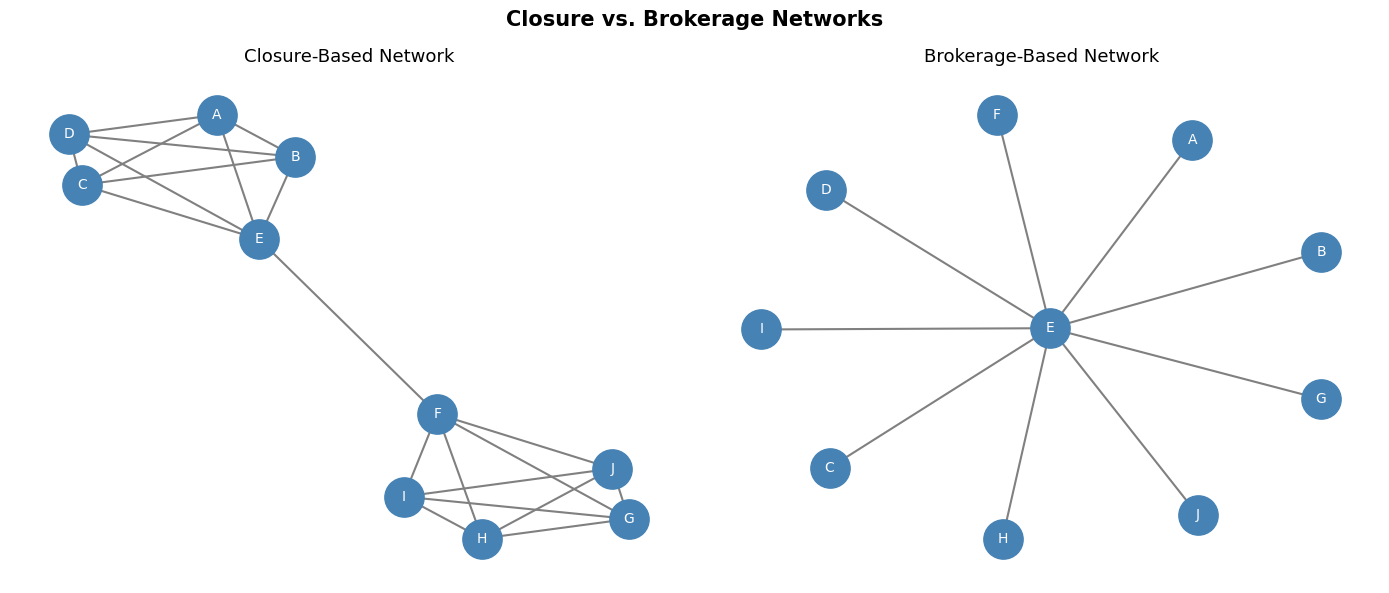

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, filename, title in zip(axes, 
                                ['closure_network.csv', 'brokerage_network.csv'],
                                ['Closure-Based Network', 'Brokerage-Based Network']):
    # Load adjacency matrix
    matrix = pd.read_csv(filename, index_col=0)
    
    # Convert to edge list
    G_sim = nx.from_pandas_adjacency(matrix)
    
    # Plot
    pos = nx.spring_layout(G_sim, seed=42)
    nx.draw_networkx(G_sim, pos, ax=ax, with_labels=True,
                     node_color='steelblue', node_size=800,
                     font_color='white', font_size=10,
                     edge_color='gray', width=1.5)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.suptitle('Closure vs. Brokerage Networks', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('closure_vs_brokerage.png', dpi=150)
plt.show()

#### Part 2.4 Reflection and Application (5 points)

Write a short reflection (1–2 paragraphs):
- In what real-life situations are you more likely to observe:
    - Closure-based networks?
    - Brokerage-based networks?
- Which type of network is closer to your own social network?

Closure based networks are most common in tight knit communities where people share a lot of context, such as friend groups, family networks, or long term coworkers in the same team. In these settings, trust builds over time and people naturally introduce their connections to each other, forming the dense triangles characteristic of closure. Brokerage based networks tend to appear in professional or cross functional settings, such as a consultant working across multiple client organizations, or a club president who connects members from different departments on campus who would otherwise never interact.
My own social network is probably closer to a closure based network. Most of my close friends know each other through shared contexts like school, work, or activities, so there is a lot of overlap and mutual connection. That said, there are some people in my network who act more like brokers, connecting me to entirely different social circles I would not otherwise have access to. Most real world networks are somewhere in between, with pockets of closure and a few key brokers bridging them.